<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Monte_Carlo_Prediction_of_US_Dollar_Inflation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install cupy-cuda12x

Backend: cupy; precision: float64
Checks passed: compounding, categorical boundaries, deterministic crossing, censoring, band ordering, occupancy, and repeatability.
CPU/GPU arithmetic and categorical checks used identical inputs; random streams are backend-specific.

Illustrative inputs; historical parameter fitting is absent.

Long-run occupancy approximation from the initial distribution:
  Stability      18.72%
  Moderate       26.40%
  Elevated       20.79%
  Crisis         34.09%
Weighted pre-clipping inflation mean: 5.96%
Simulated fraction of clipped rate draws: 0.0000%

Unconditional first passage quantiles:
     5%: 63 years
    25%: 75 years
    50%: 87 years
    75%: 100 years
    95%: 123 years

Fraction reaching threshold by each year (Monte Carlo SE):
    50:    0.13% (SE 0.011%)
   100:   75.39% (SE 0.136%)
   150:   99.60% (SE 0.020%)
   200:  100.00% (SE 0.000%)
   300:  100.00% (SE 0.000%)
   500:  100.00% (SE 0.000%)
Right-censored trajectories: 0.00%
Monte Carlo SE

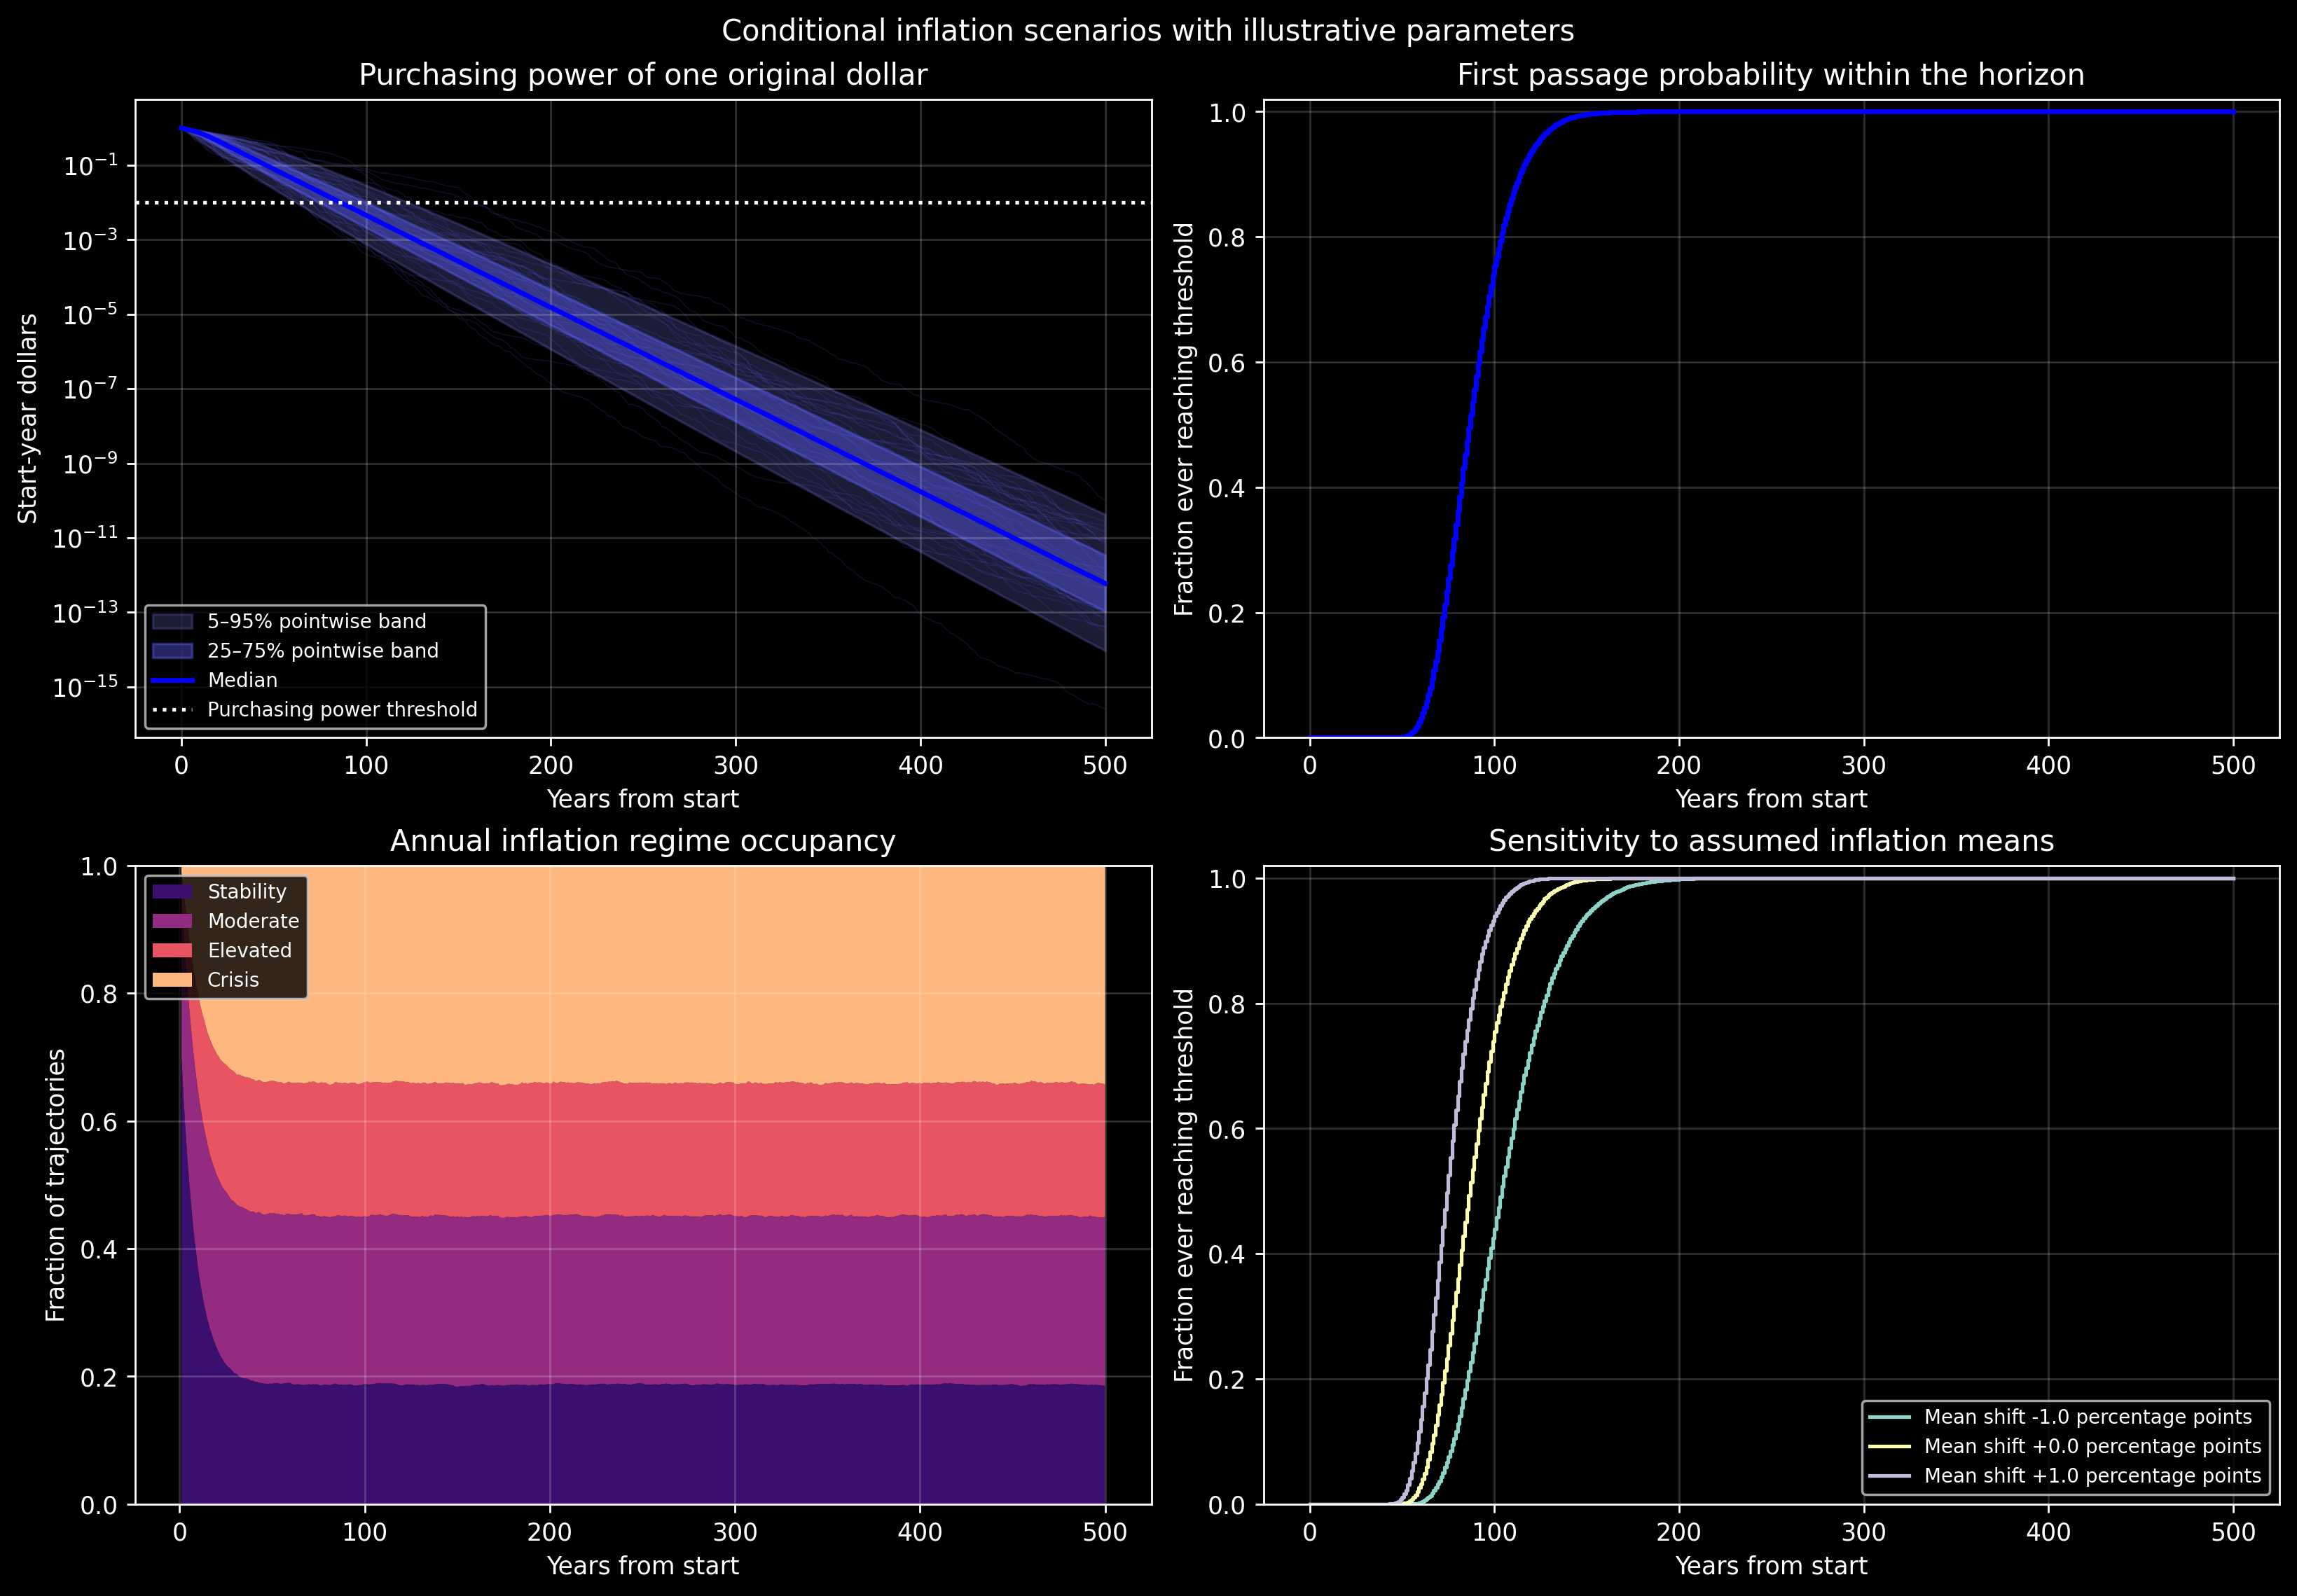

In [3]:
"""Explore dollar purchasing power with GPU Monte Carlo inflation scenarios.

Annual purchasing power follows V[t] = exp(-sum(log1p(inflation))).
Inputs are illustrative assumptions, without historical parameter fitting.
First passage measures the first annual observation at or below the threshold.
Unreached thresholds are right censored at the simulation horizon. Currency
conversion changes the unit of account while preserving purchasing power.
This model provides conditional scenarios, without predicting policy decisions.

References:
    https://www.bls.gov/cpi/data.htm
    https://docs.cupy.dev/en/stable/reference/random.html

"""

import time

import matplotlib.pyplot as plt
import numpy as np

# --- Control knobs ------------------------------------------------------------
NUM_TRAJECTORIES = 100_000
SIMULATION_HORIZON_YEARS = 500
RANDOM_SEED = 42
BACKEND = "auto"  # "auto", "cupy", or "numpy".
PRECISION = "float64"  # Accumulated logarithms benefit from float64.
REGIME_SWITCHING = True
BASELINE_INFLATION_MEAN = 0.025
BASELINE_INFLATION_STD = 0.015
REGIME_STATES = {
    "Stability": {"mean": 0.020, "std": 0.010},
    "Moderate": {"mean": 0.035, "std": 0.020},
    "Elevated": {"mean": 0.060, "std": 0.030},
    "Crisis": {"mean": 0.100, "std": 0.050},
}
# Original assumptions retained. The report exposes long-run regime occupancy.
REGIME_TRANSITION_MATRIX = [
    [0.90, 0.08, 0.01, 0.01],
    [0.05, 0.80, 0.10, 0.05],
    [0.01, 0.10, 0.70, 0.19],
    [0.01, 0.05, 0.10, 0.84],
]
INITIAL_REGIME_PROBABILITY = [0.70, 0.25, 0.04, 0.01]
INFLATION_BOUNDS = (-0.20, 2.00)  # Clipping bounds, separate from physical limits.
PURCHASING_POWER_THRESHOLD = 0.01
PERCENTILES = [0.05, 0.25, 0.50, 0.75, 0.95]
TIME_WINDOWS_YEARS = [50, 100, 150, 200, 300, 500]
SAMPLE_PATHS = 30
QUANTILE_STRIDE_YEARS = 5  # Full ensemble bands every five years; hits every year.
SENSITIVITY_ENABLED = True
SENSITIVITY_MEAN_SHIFTS = [-0.01, 0.0, 0.01]  # Additive annual rate shifts.
SENSITIVITY_TRAJECTORIES = 20_000
REDENOMINATION_ENABLED = False
REDENOMINATION_MEAN_YEAR = 250.0
REDENOMINATION_STD_YEAR = 50.0
REDENOMINATION_CONVERSION_FACTOR = 100.0  # 100 old units = 1 new unit.
PLOT_DPI = 250
RUN_CHECKS = True


def select_backend():
    """Return a working array backend, probing CUDA before allocating paths."""
    if BACKEND not in {"auto", "cupy", "numpy"}:
        raise ValueError("BACKEND must be auto, cupy, or numpy.")
    if BACKEND == "numpy":
        return np
    try:
        import cupy as cp  # Optional GPU dependency.
        if cp.cuda.runtime.getDeviceCount() < 1:
            raise RuntimeError("CUDA device count is zero.")
        cp.zeros(1).sum().item()
        return cp
    except Exception as exc:
        if BACKEND == "cupy":
            raise RuntimeError("Requested CUDA backend is unavailable.") from exc
        print(f"Using NumPy CPU fallback: {type(exc).__name__}: {exc}")
        return np


def to_host(array, xp):
    """Return a NumPy array from either supported backend."""
    return np.asarray(array) if xp is np else xp.asnumpy(array)


def parameters():
    """Validate control knobs and return ordered inflation model arrays."""
    for value in (NUM_TRAJECTORIES, SIMULATION_HORIZON_YEARS,
                  QUANTILE_STRIDE_YEARS, SAMPLE_PATHS,
                  SENSITIVITY_TRAJECTORIES):
        if isinstance(value, bool) or int(value) != value or value < 1:
            raise ValueError("Counts and time steps must be positive integers.")
    if PRECISION not in {"float32", "float64"}:
        raise ValueError("PRECISION must be float32 or float64.")
    if not 0 < PURCHASING_POWER_THRESHOLD < 1:
        raise ValueError("Purchasing power threshold must be between 0 and 1.")
    lower, upper = INFLATION_BOUNDS
    if not np.isfinite([lower, upper]).all() or not -1 < lower < upper:
        raise ValueError("Finite inflation bounds must satisfy -1 < lower < upper.")
    q = np.asarray(PERCENTILES)
    if q.size == 0 or np.any((q <= 0) | (q >= 1)):
        raise ValueError("Percentile probabilities must lie between 0 and 1.")
    if any(int(w) != w or w < 1 for w in TIME_WINDOWS_YEARS):
        raise ValueError("Time windows must be positive whole years.")
    if not np.isfinite(SENSITIVITY_MEAN_SHIFTS).all():
        raise ValueError("Sensitivity shifts must be finite.")
    if REDENOMINATION_ENABLED:
        if (not np.isfinite([REDENOMINATION_MEAN_YEAR,
                             REDENOMINATION_STD_YEAR,
                             REDENOMINATION_CONVERSION_FACTOR]).all()
                or REDENOMINATION_MEAN_YEAR <= 0
                or REDENOMINATION_STD_YEAR < 0
                or REDENOMINATION_CONVERSION_FACTOR <= 0):
            raise ValueError("Currency conversion parameters are invalid.")
    if REGIME_SWITCHING:
        names = list(REGIME_STATES)
        means = np.array([REGIME_STATES[s]["mean"] for s in names])
        stds = np.array([REGIME_STATES[s]["std"] for s in names])
        matrix = np.asarray(REGIME_TRANSITION_MATRIX, dtype=float)
        initial = np.asarray(INITIAL_REGIME_PROBABILITY, dtype=float)
    else:
        names = ["Baseline"]
        means = np.array([BASELINE_INFLATION_MEAN])
        stds = np.array([BASELINE_INFLATION_STD])
        matrix = np.ones((1, 1))
        initial = np.ones(1)
    k = len(names)
    if matrix.shape != (k, k) or initial.shape != (k,):
        raise ValueError("Regime array dimensions must agree.")
    if (not np.isfinite(matrix).all() or np.any(matrix < 0)
            or not np.allclose(matrix.sum(axis=1), 1.0)
            or not np.isfinite(initial).all() or np.any(initial < 0)
            or not np.isclose(initial.sum(), 1.0)):
        raise ValueError("Probability rows must be finite, nonnegative, and sum to 1.")
    if (not np.isfinite(means).all() or not np.isfinite(stds).all()
            or np.any(stds < 0)):
        raise ValueError("Inflation moments must be finite with nonnegative std.")
    return names, means, stds, matrix, initial


def draw_states(cdf_rows, uniforms, xp):
    """Sample categorical states using one uniform per trajectory."""
    return xp.sum(uniforms[:, None] >= cdf_rows, axis=1).astype(xp.int32)


def simulate(xp, model, count, years, seed, mean_shift=0.0, summaries=True):
    """Stream annual inflation using storage proportional to path count.

    Args:
        xp: NumPy or CuPy module.
        model: Ordered names, means, stds, transition matrix, initial weights.
        count: Number of independent paths.
        years: Annual observation horizon.
        seed: Backend-local random seed, or None.
        mean_shift: Additive shift to every regime's pre-clipping mean.
        summaries: Whether to retain bands, sample paths, and occupancy.

    Returns:
        Dictionary of CPU arrays, including censored first passage times.
        A hit time of years + 1 denotes an unreached threshold.
    """
    names, means, stds, matrix, initial = model
    rng = xp.random.RandomState(seed)
    dtype = getattr(xp, PRECISION)
    means_gpu = xp.asarray(means + mean_shift, dtype=dtype)
    stds_gpu = xp.asarray(stds, dtype=dtype)
    transition_cdf = xp.asarray(np.cumsum(matrix, axis=1))
    transition_cdf[:, -1] = 1.0
    initial_cdf = xp.asarray(np.cumsum(initial))
    initial_cdf[-1] = 1.0
    states = draw_states(initial_cdf[None, :], rng.random_sample(count), xp)
    log_value = xp.zeros(count, dtype=dtype)
    hits = xp.full(count, years + 1, dtype=xp.int32)
    boundary = np.log(PURCHASING_POWER_THRESHOLD)
    sample_count = min(count, SAMPLE_PATHS)
    samples = xp.zeros((years + 1, sample_count), dtype=dtype)
    observation_years = np.unique(np.r_[
        np.arange(0, years + 1, QUANTILE_STRIDE_YEARS), years])
    bands = xp.zeros((len(observation_years), 5), dtype=dtype)
    occupancy = xp.zeros((years, len(names)), dtype=xp.int64)
    band_index = 1
    clipped = xp.zeros((), dtype=xp.int64)
    for year in range(1, years + 1):
        # Inflation in year one uses the supplied initial regime distribution.
        raw = means_gpu[states] + stds_gpu[states] * rng.standard_normal(count)
        clipped += xp.count_nonzero(
            (raw < INFLATION_BOUNDS[0]) | (raw > INFLATION_BOUNDS[1]))
        rates = xp.clip(raw, *INFLATION_BOUNDS).astype(dtype)
        log_value -= xp.log1p(rates)
        hits = xp.where((hits == years + 1) & (log_value <= boundary),
                        year, hits)
        if summaries:
            samples[year] = log_value[:sample_count]
            occupancy[year - 1] = xp.bincount(states, minlength=len(names))
            if year == observation_years[band_index]:
                bands[band_index] = xp.percentile(
                    log_value, xp.asarray([5, 25, 50, 75, 95]))
                band_index += 1
        # No Python loop over trajectories or device-to-host scalar reads.
        states = draw_states(transition_cdf[states],
                             rng.random_sample(count), xp)
    return {
        "hits": to_host(hits, xp),
        "years": years,
        "count": count,
        "band_years": observation_years,
        "bands": np.exp(to_host(bands, xp)),
        "samples": np.exp(to_host(samples, xp)),
        "occupancy": to_host(occupancy, xp) / count,
        "clipped_fraction": float(to_host(clipped, xp)) / (count * years),
    }


def passage_quantile(hits, q, horizon):
    """Return an empirical first passage quantile or a censoring label."""
    # Inverse empirical CDF avoids interpolation with censored observations.
    index = max(0, int(np.ceil(q * hits.size)) - 1)
    value = int(np.partition(hits, index)[index])
    return f"> {horizon} years (censored)" if value > horizon else f"{value} years"


def report(result, model):
    """Print regime diagnostics and unconditional threshold statistics."""
    names, means, _, matrix, initial = model
    print("\nIllustrative inputs; historical parameter fitting is absent.")
    # Cesaro averaging also handles periodic or reducible transition matrices.
    weights = initial.copy()
    average = np.zeros_like(weights)
    for _ in range(20_000):
        average += weights
        weights = weights @ matrix
    average /= 20_000
    print("\nLong-run occupancy approximation from the initial distribution:")
    for name, weight in zip(names, average):
        print(f"  {name:<12} {weight:8.2%}")
    print(f"Weighted pre-clipping inflation mean: {average @ means:.2%}")
    print(f"Simulated fraction of clipped rate draws: "
          f"{result['clipped_fraction']:.4%}")
    print("\nUnconditional first passage quantiles:")
    for q in PERCENTILES:
        print(f"  {q:5.0%}: {passage_quantile(result['hits'], q, result['years'])}")
    print("\nFraction reaching threshold by each year (Monte Carlo SE):")
    for window in TIME_WINDOWS_YEARS:
        if window > result["years"]:
            print(f"  {window:4d}: outside simulated horizon")
            continue
        fraction = np.mean(result["hits"] <= window)
        error = np.sqrt(fraction * (1 - fraction) / result["count"])
        print(f"  {window:4d}: {fraction:8.2%} (SE {error:.3%})")
    censored = np.mean(result["hits"] > result["years"])
    print(f"Right-censored trajectories: {censored:.2%}")
    print("Monte Carlo SE excludes uncertainty in model assumptions.")


def verify(xp, model):
    """Check compounding, censoring, categorical sampling, and repeatability."""
    rates = np.array([[0.02, -0.03], [0.04, 0.01], [-0.01, 0.05]])
    expected = 1 / np.cumprod(1 + rates, axis=0)
    actual = to_host(xp.exp(-xp.cumsum(xp.log1p(xp.asarray(rates)),
                                     axis=0)), xp)
    np.testing.assert_allclose(actual, expected, rtol=1e-12)
    uniforms = np.array([0.0, 0.2, 0.9, 0.999])
    rows = np.tile([0.2, 0.9, 1.0], (4, 1))
    np.testing.assert_array_equal(
        to_host(draw_states(xp.asarray(rows), xp.asarray(uniforms), xp), xp),
        [0, 1, 2, 2])
    deterministic = (["Fixed"], np.array([0.05]), np.array([0.0]),
                     np.ones((1, 1)), np.ones(1))
    exact = -np.log(PURCHASING_POWER_THRESHOLD) / np.log1p(0.05)
    horizon = int(np.ceil(exact)) + 2
    fixed = simulate(xp, deterministic, 4, horizon, 7)
    np.testing.assert_array_equal(fixed["hits"], int(np.ceil(exact)))
    np.testing.assert_allclose(fixed["samples"][:, 0],
                               (1.05) ** -np.arange(horizon + 1), rtol=2e-4)
    zero = (["Zero"], np.zeros(1), np.zeros(1), np.ones((1, 1)), np.ones(1))
    np.testing.assert_array_equal(simulate(xp, zero, 4, 10, 7)["hits"], 11)
    assert "censored" in passage_quantile(np.array([1, 11, 11]), 0.5, 10)
    first = simulate(xp, model, 64, 12, 7)
    second = simulate(xp, model, 64, 12, 7)
    np.testing.assert_array_equal(first["samples"], second["samples"])
    assert np.all(np.diff(first["bands"], axis=1) >= 0)
    np.testing.assert_allclose(first["occupancy"].sum(axis=1), 1)
    print("Checks passed: compounding, categorical boundaries, deterministic "
          "crossing, censoring, band ordering, occupancy, and repeatability.")
    if xp is np:
        print("CUDA agreement check requires a GPU runtime; CPU checks completed.")
    else:
        print("CPU/GPU arithmetic and categorical checks used identical inputs; "
              "random streams are backend-specific.")


def plot_results(result, model, sensitivity):
    """Render scenario bands, crossing CDFs, regime shares, and sensitivity."""
    plt.style.use("dark_background")
    plt.rcParams.update({"figure.dpi": PLOT_DPI, "savefig.dpi": PLOT_DPI,
                         "font.size": 10, "axes.grid": True,
                         "grid.alpha": 0.18})
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained")
    years = np.arange(result["years"] + 1)
    x = result["band_years"]
    bands = result["bands"]
    ax = axes[0, 0]
    ax.plot(years, result["samples"], color="#6060ff", alpha=0.14, lw=0.5)
    ax.fill_between(x, bands[:, 0], bands[:, 4], color="#8080ff",
                    alpha=0.22, label="5–95% pointwise band")
    ax.fill_between(x, bands[:, 1], bands[:, 3], color="#6060ff", alpha=0.4,
                    label="25–75% pointwise band")
    ax.plot(x, bands[:, 2], color="#0000ff", lw=2, label="Median")
    ax.axhline(PURCHASING_POWER_THRESHOLD, color="white", ls=":",
               label="Purchasing power threshold")
    ax.set(yscale="log", xlabel="Years from start", ylabel="Start-year dollars",
           title="Purchasing power of one original dollar")
    ax.legend(fontsize=8)
    ax = axes[0, 1]
    counts = np.bincount(result["hits"], minlength=result["years"] + 2)
    cdf = np.cumsum(counts[:result["years"] + 1]) / result["count"]
    ax.step(years, cdf, where="post", color="#0000ff", lw=2)
    ax.set(xlabel="Years from start", ylabel="Fraction ever reaching threshold",
           ylim=(0, 1.02), title="First passage probability within the horizon")
    ax = axes[1, 0]
    ax.stackplot(years[1:], result["occupancy"].T, labels=model[0],
                 colors=plt.cm.magma(np.linspace(0.2, 0.85, len(model[0]))))
    ax.set(xlabel="Years from start", ylabel="Fraction of trajectories",
           ylim=(0, 1), title="Annual inflation regime occupancy")
    ax.legend(fontsize=8, loc="upper left")
    ax = axes[1, 1]
    for shift, hits in sensitivity:
        counts = np.bincount(hits, minlength=result["years"] + 2)
        cdf = np.cumsum(counts[:result["years"] + 1]) / hits.size
        ax.step(years, cdf, where="post",
                label=f"Mean shift {100 * shift:+.1f} percentage points")
    ax.set(xlabel="Years from start", ylabel="Fraction ever reaching threshold",
           ylim=(0, 1.02), title="Sensitivity to assumed inflation means")
    if sensitivity:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "Sensitivity disabled", transform=ax.transAxes,
                ha="center")
    fig.suptitle("Conditional inflation scenarios with illustrative parameters")
    plt.show()
    if REDENOMINATION_ENABLED:
        plot_conversion(result)
    return fig


def plot_conversion(result):
    """Show one independent hypothetical unit conversion and its real value."""
    rng = np.random.default_rng(RANDOM_SEED)
    mean = REDENOMINATION_MEAN_YEAR
    sigma = np.sqrt(np.log1p((REDENOMINATION_STD_YEAR / mean) ** 2))
    event = max(1, int(np.ceil(rng.lognormal(np.log(mean) - sigma ** 2 / 2,
                                            sigma))))
    years = np.arange(result["years"] + 1)
    value = result["samples"][:, 0]
    factor = REDENOMINATION_CONVERSION_FACTOR
    converted = years >= event
    # One original dollar becomes 1/factor new units. A new unit buys factor
    # times as much as an old unit, preserving the original holder's real value.
    balance = np.where(converted, 1 / factor, 1.0)
    unit_value = value * np.where(converted, factor, 1.0)
    np.testing.assert_allclose(balance * unit_value, value)
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), layout="constrained",
                             sharex=True)
    axes[0].plot(years, value, color="#0000ff", lw=2,
                 label="Real value of the original holding")
    axes[0].plot(years, unit_value, color="orange", ls="--",
                 label="Real value of one prevailing currency unit")
    axes[0].set(yscale="log", ylabel="Start-year dollars",
                title="Hypothetical redenomination on one sampled path")
    axes[1].step(years, balance, where="post", color="#0000ff",
                 label="Nominal balance of the original holding")
    axes[1].set(yscale="log", xlabel="Years from start",
                ylabel="Prevailing currency units")
    for ax in axes:
        if event <= result["years"]:
            ax.axvline(event, color="white", ls=":", label=f"Conversion year {event}")
        ax.legend(fontsize=8)
    print(f"Hypothetical conversion drawn at year {event}: "
          f"{factor:g} old units = 1 new unit.")
    if event > result["years"]:
        print("The sampled event lies beyond the plotted horizon.")
    plt.show()


def main():
    """Run the configured model and return reusable arrays and the figure."""
    model = parameters()
    xp = select_backend()
    print(f"Backend: {xp.__name__}; precision: {PRECISION}")
    if RUN_CHECKS:
        verify(xp, model)
    start = time.perf_counter()
    result = simulate(xp, model, NUM_TRAJECTORIES,
                      SIMULATION_HORIZON_YEARS, RANDOM_SEED)
    report(result, model)
    sensitivity = []
    if SENSITIVITY_ENABLED:
        # Shared seeds within this sweep reduce comparison noise on one backend.
        for shift in SENSITIVITY_MEAN_SHIFTS:
            trial = simulate(xp, model, SENSITIVITY_TRAJECTORIES,
                             SIMULATION_HORIZON_YEARS, RANDOM_SEED,
                             mean_shift=shift, summaries=False)
            sensitivity.append((shift, trial["hits"]))
            print(f"Mean shift {shift:+.1%}: median first passage "
                  f"{passage_quantile(trial['hits'], 0.5, trial['years'])}")
    print(f"Simulation and summaries: {time.perf_counter() - start:.1f} seconds")
    figure = plot_results(result, model, sensitivity)
    return result, sensitivity, figure


if __name__ == "__main__":
    RESULTS, SENSITIVITY_RESULTS, FIGURE = main()